In [1]:
import pandas as pd
import numpy as np
import sklearn as sk

In [2]:
from google.cloud import bigquery
from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import requests

In [131]:
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, KFold
from sklearn.metrics import mean_absolute_error, r2_score

In [4]:
rj_path_to_key = '/Users/ryan/Library/Mobile Documents/com~apple~CloudDocs/cbb-airflow/config/secrets/cbbanalytics-dc41bfd9d12d.json'
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = rj_path_to_key

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
#Set up BigQuery client
bq = bigquery.Client()

In [30]:
#Load enhanced nil values dataframe
enhanced_nil_query = """
select *
    from models.gs__enh_nil_values
"""
enhanced_nil_df = bq.query(enhanced_nil_query).to_dataframe()
enhanced_nil_df.head()

,competitionId,gender,rawSource,teamIdFrom,teamMarketFrom,isSameTeam,isKeeper,isFiller,isDummy,value,playerId,jerseyNum,fullName,classYr,position,hasImage,teamIdTo,teamMarketTo,conferenceIdFrom,conferenceIdTo,confTierFrom,confTierTo,per,rapm,warpP40,wsP40,dwsP40,owsP40,mins,minsPg,gs,gp,tsPct,usagePct,fg3Pct,fga3Pg,fgaPg,fgaP40,fga3Rate,ptsScoredPg,orbPct,drbPct,astPct,stlPct,blkPct,pfEff,pfP40,pfPg,astTov,tovPct,fg2Pct,fga3P40,height,atr2FgaFreq,atr2FgPct,atr2FgaP40,sflDrawnPct,and1Pct,fgmAstdPct,ptsScoredPgTm,fgaPgTm,netRtgTm,netRtgAdjTm,ptsShare,fgaShare,confAvgNetRtgFrom,confAvgNetRtgFromSignedSq
0,33533,MALE,spreadsheet,103865,Marshall,0,1,0,0,600000.0,1296979,0,Andrew Taylor,Senior,G,True,104051,Ole Miss,62,89,low,high,19.5044,2.640,0.1645,0.1362,0.0695,0.0667,1145.54,36.95290,31,31,0.50494,0.29551,0.35909,7.09677,18.93548,20.49688,0.37479,20.09677,0.03359,0.09730,0.23729,0.03194,0.00000,1.27451,1.78082,1.64516,1.61538,0.12855,0.44959,7.68197,75.0,0.1448,0.7176,2.96803,0.0400,0.4583,0.3402,81.19355,65.74194,13.84700,13.6982,0.2475,0.2880,0.30,0.09
1,36046,MALE,notebook,104355,UC San Diego,0,1,1,1,0.0,1308295,25,Emmanuel Tshimanga,Senior,F,True,103470,Clemson,40,53,low,high,18.9047,-0.489,0.1784,0.1622,0.0918,0.0703,311.16,14.14364,0,22,0.61580,0.15871,NaN,0.00000,2.45455,6.94177,0.00000,4.18182,0.12842,0.29733,0.03593,0.02571,0.05320,0.45161,7.97018,2.81818,0.33333,0.19422,0.59259,0.00000,84.0,0.6481,0.5714,4.49929,0.3380,0.2917,0.6875,74.70968,58.06452,7.35457,5.9235,0.0560,0.0423,-0.83,-0.69
2,36046,MALE,notebook,104453,Western Ky.,0,1,1,1,-1.0,1309578,11,Dontaie Allen,Senior,G,True,104508,Wyoming,88,87,low,mid,13.3045,3.331,0.1028,0.1172,0.0704,0.0468,634.11,21.13700,13,30,0.58345,0.18506,0.42149,4.03333,6.46667,12.23762,0.62371,8.36667,0.01744,0.13184,0.05058,0.01702,0.01529,0.58000,3.15403,1.66667,0.55882,0.13648,0.43836,7.63275,78.0,0.1495,0.6552,1.82934,0.0922,0.3684,0.6386,78.77419,62.25806,5.53334,3.6792,0.1062,0.1039,-1.26,-1.59
3,33533,MALE,spreadsheet,103643,Georgetown,0,1,0,0,400000.0,1309669,11,Akok Akok,Junior,F,True,104448,West Virginia,29,60,high,high,13.4132,-1.429,0.0642,0.0553,0.0308,0.0244,931.58,30.05097,31,31,0.53961,0.12153,0.28235,2.74194,5.74194,7.64293,0.47753,6.54839,0.04867,0.17987,0.05831,0.01127,0.07020,1.56863,2.18983,1.64516,0.76923,0.17172,0.61290,3.64971,82.0,0.2697,0.8125,2.06101,0.0541,0.3000,0.8395,69.53125,60.43750,-12.46880,-9.9053,0.0942,0.0950,4.52,20.43
4,36046,MALE,notebook,103530,Delaware,0,1,1,1,-1.0,1310161,1,Gerald Drumgoole Jr.,Senior,F,True,103642,George Washington,16,4,low,mid,17.9296,-1.448,0.1646,0.1272,0.0479,0.0794,909.43,28.41969,18,32,0.56427,0.25775,0.37500,6.25000,10.78125,15.17434,0.57971,13.93750,0.02509,0.12080,0.16181,0.00865,0.00696,0.41304,2.02325,1.43750,1.46000,0.11232,0.51034,8.79672,77.0,0.1855,0.6719,2.81495,0.1250,0.1875,0.5302,72.34375,57.59375,3.95410,1.9220,0.1927,0.1872,-1.90,-3.61


In [35]:
df_raw = enhanced_nil_df.copy()

In [ ]:
# df_raw['value'] = np.where(df_raw['value'] < 0, 0, df_raw['value'])

In [111]:
# df_raw = df_raw[df_raw['value'] >= 0]
# df_raw = df_raw[df_raw['minsPg'] >= 15]
# df_raw = df_raw[(df_raw['isFiller'] == 0) & (df_raw['isDummy'] == 0)]
# df_raw = df_raw[df_raw['value'] > 0]  # also require positive value like the original
df_raw = df_raw[df_raw['value'] > 0]
df_raw = df_raw[df_raw['minsPg'] >= 15]

print(f'Total NIL records: {len(df_raw)}')
print(df_raw['gender'].value_counts())

Total NIL records: 385
gender
MALE      283
FEMALE    102
Name: count, dtype: int64


In [12]:
compids = df_raw['competitionId'].unique()
print(f'Competition IDs: {compids}')

all_stats = []
for cid in compids:
    url = f'https://api.cbbanalytics.com/api/gs/player-agg-stats-public?competitionId={cid}&divisionId=1&scope=season'
    data = requests.get(url).json()
    all_stats.append(pd.DataFrame(data))
    print(f'  cid={cid}: {len(data)} rows')

allstatsdf = pd.concat(all_stats, ignore_index=True)
print(f'Total stats rows: {len(allstatsdf)}')

Competition IDs: <IntegerArray>
[33533, 36046, 38529, 38409, 36045]
Length: 5, dtype: Int64
  cid=33533: 5049 rows
  cid=36046: 5006 rows
  cid=38529: 4723 rows
  cid=38409: 5063 rows
  cid=36045: 4655 rows
Total stats rows: 24496


In [120]:
df_merged = df_raw[['competitionId', 'playerId', 'value']].merge(
    allstatsdf, on=['competitionId', 'playerId'], how='left'
)

print(f'Merged rows: {len(df_merged)}')
print(df_merged['gender'].value_counts())

Merged rows: 385
gender
MALE      283
FEMALE    102
Name: count, dtype: int64


In [54]:
corr = df_merged.drop(columns=['nextConferenceId','nextTeamId']).corr(numeric_only=True)['value'].reset_index()
corr['absolute_corr'] = corr['value'].abs()
corr = corr.sort_values(by='absolute_corr', ascending=False)
print('Correlation with NIL value:')
print(corr[corr['absolute_corr'] >= corr['absolute_corr'].mean()][['index', 'value']])

Correlation with NIL value:
               index     value
2              value  1.000000
6    isDraftProspect  0.497006
27         ptsScored  0.468966
29               fgm  0.468258
152               ws  0.464253
..               ...       ...
65           fgaAgst  0.260700
66          fga3Agst  0.260436
57             rebTm  0.260039
56             drbTm  0.258382
107             pfPg  0.257242

[81 rows x 2 columns]


In [55]:
feats = corr[corr['absolute_corr'] >= corr['absolute_corr'].mean()]['index'].tolist()
feats.remove('value')
print(f'Features used for modeling: {feats}')

Features used for modeling: ['isDraftProspect', 'ptsScored', 'fgm', 'ws', 'warp', 'scp', 'pitp', 'vps', 'ptsScoredPg', 'fgm2', 'ows', 'fta', 'rapm', 'ortgPlayer', 'ftm', 'ftaPg', 'orapm', 'pitpPg', 'ptsScoredP40', 'per', 'warpP40', 'scpPg', 'tsa', 'pfd', 'wsP40', 'fga', 'fga2', 'owsP40', 'pfdPg', 'dws', 'possPbp', 'poss', 'minsPbp', 'mins', 'reb', 'ftaTm', 'drb', 'fgaPg', 'plusMinus', 'tsPct', 'rebPg', 'fga2Pg', 'drbPg', 'minsPg', 'fgmTm', 'minsThreshold', 'gs', 'blkd', 'ftaP40', 'blk', 'height', 'dpf', 'orb', 'efgPct', 'blkPg', 'fgPct', 'blkdPg', 'fbpts', 'ast', 'pf', 'pitpP40', 'orbPg', 'fbptsPg', 'astPg', 'teamId', 'pfdP40', 'tovPct', 'fgaP40', 'dpfPg', 'fgaTm', 'conferenceId', 'usagePct', 'priorConferenceId', 'drapm', 'blkPerPf', 'fgaAgst', 'fga3Agst', 'rebTm', 'drbTm', 'pfPg']


In [38]:
df_merged.head(2)

,competitionId,playerId,value,_id,gender,teamId,scope,tournamentId,fullName,jerseyNum,height,position,classYr,isDraftProspect,hasImage,teamMarket,teamName,conferenceId,divisionId,nextTeamId,nextTeamMarket,nextConferenceId,nextCompetitionId,priorTeamId,priorTeamMarket,priorConferenceId,priorCompetitionId,isTransfer,willTransfer,inPortalAfterSeason,draftRn,draftRp,draftOp,updated,gs,gp,gpPbp,mins,minsPbp,poss,possPbp,ptsScored,plusMinus,fgm,fga,fgm2,fga2,fgm3,fga3,fta,ftm,ast,orb,drb,reb,stl,blk,blkd,tov,tf,pf,pfd,opf,dpf,pitp,scp,fbpts,minsTm,dPossTm,orbTm,drbTm,rebTm,fgmTm,fgaTm,ftaTm,tovTm,drbAgst,orbAgst,rebAgst,fgaAgst,fga3Agst,ledTeamIn,ledGameIn,minsTmBy5,tsa,minsPg,minsP40,ptsScoredPg,ptsScoredP40,fgaPg,fgaP40,fga2Pg,fga2P40,fga3Pg,fga3P40,ftaPg,ftaP40,astPg,astP40,orbPg,orbP40,drbPg,drbP40,rebPg,rebP40,stlPg,stlP40,blkPg,blkP40,pfdPg,pfdP40,tfPg,tfP40,scpPg,scpP40,pitpPg,pitpP40,fbptsPg,fbptsP40,blkdPg,blkdP40,tovPg,tovP40,pfPg,pfP40,opfPg,opfP40,dpfPg,dpfP40,fgPct,fg2Pct,fg3Pct,fga3Rate,ftPct,efgPct,tsPct,ftaRate,ftmRate,orbPct,drbPct,rebPct,astTov,astPct,astRatio,blkPct,blkdPerFga,pfdPerFga,stlPct,tovPct,stlTov,usagePct,pfEff,stlPerPf,blkPerPf,scpPctPts,fbptsPctPts,pitpPctPts,ftmPctPts,fgm2PctPts,fgm3PctPts,vps,hkmPct,astUsage,per,warp,warpP40,ortgPlayer,drtgPlayer,ws,ows,dws,wsP40,owsP40,dwsP40,rapm,orapm,drapm,minsThreshold,isQualified
0,33533,1296979,600000.0,33533-103865-1296979-season-0,MALE,103865,season,0,Andrew Taylor,0,75.0,G,Senior,False,True,Marshall,Thundering Herd,62,1,103926.0,Mississippi St.,89.0,36046,103865.0,Marshall,88.0,30629,False,True,False,NaN,NaN,NaN,2023-12-04T18:40:01Z,31,31,31.0,1145.54,1145.54,2034.560,2034.55995,623,295.0,244,587,165,367,79,220,68,56,147,36,108,144,65,0,12.0,91,0,51,70.0,9.0,42,238.0,94.0,86.0,6275.000,2229.77324,372,819,1191,946,2038,533,352,802,397,1199,1947,662,"{'pts': 13, 'reb': 3, 'ast': 14, 'stl': 15, 'b...","{'pts': 12, 'reb': 0, 'ast': 9, 'stl': 12, 'bl...",1255.000,616.9,36.95290,40.0,20.09677,21.75393,18.93548,20.49688,11.83871,12.81492,7.09677,7.68197,2.19355,2.37443,4.74194,5.13295,1.16129,1.25705,3.48387,3.77115,4.64516,5.02820,2.09677,2.26967,0.0,0.00000,2.25806,2.44426,0.0,0.0,3.03226,3.28229,7.67742,8.31049,2.77419,3.00295,0.38710,0.41902,2.93548,3.17754,1.64516,1.78082,0.29032,0.31426,1.35484,1.46656,0.41567,0.44959,0.35909,0.37479,0.82353,0.48296,0.50494,0.11584,0.09540,0.03359,0.09730,0.06601,1.61538,0.23729,0.17195,0.0000,0.02044,0.11925,0.03194,0.12855,0.71429,0.29551,1.27451,1.27451,0.00000,0.15088,0.13804,0.38202,0.08989,0.52970,0.38042,1.35540,0.03194,0.80298,19.5033,4.71103,0.1645,104.41,99.92,3.9008,1.9103,1.9905,0.1362,0.0667,0.0695,2.640,2.512,0.128,110.44,True
1,33533,1309669,400000.0,33533-103643-1309669-season-0,MALE,103643,season,0,Akok Akok,11,82.0,F,Junior,False,True,Georgetown,Hoyas,29,1,104448.0,West Virginia,60.0,36046,104361.0,UConn,29.0,30629,True,True,False,NaN,NaN,NaN,2024-09-28T01:18:08Z,31,31,31.0,931.58,931.58,1598.719,1598.71910,203,-211.0,81,178,57,93,24,85,23,17,30,42,150,192,18,62,4.0,39,0,51,21.0,5.0,46,88.0,46.0,38.0,6250.025,2142.21937,341,783,1124,799,1878,556,385,817,336,1153,1941,756,"{'pts': 2, 'reb': 11, 'ast': 1, 'stl': 3, 'blk...","{'pts': 0, 'reb': 6, 'ast': 0, 'stl': 1, 'blk'...",1250.005,188.1,30.05097,40.0,6.54839,8.71637,5.74194,7.64293,3.00000,3.99322,2.74194,3.64971,0.74194,0.98757,0.96774,1.28813,1.35484,1.80339,4.83871,6.44067,6.19355,8.24406,0.58065,0.77288,2.0,2.66214,0.67742,0.90169,0.0,0.0,1.48387,1.97514,2.83871,3.77853,1.22581,1.63164,0.12903,0.17175,1.25806,1.67457,1.64516,2.18983,0.16129,0.21469,1.48387,1.97514,0.45506,0.61290,0.28235,0.47753,0.73913,0.52247,0.53961,0.12921,0.09551,0.04867,0.17987,0.11314,0.76923,0.05831,0.11668,0.0702,0.02247,0.11798,0.01127,0.17172,0.46154,0.12153,1.56863,0.35294,1.21569,0.22660,0.18719,0.43350,0.08374,0.56158,0.35468,1.72895,0.08147,0.47980,13.4126,1.49449,0.0642,102.61,110.20,1.2868,0.5688,0.7181,0.0553,0.0244,0.0308,-1.429,-0.664,-0.765,110.44,True


In [132]:
CANDIDATE_FEATURES = [
    # --- 1. Market signal / upside ---
    'isDraftProspect',
    'height',
    'ws',

    # --- 2. Core production (PRIMARY DRIVER) ---
    'ptsScoredPg',
    'astPg',
    'rebPg',
    'usagePct',
    'minsPg',

    # --- 3. Shot creation / scoring load ---
    'fgaPg',
    'fga3Pg',

    # --- 4. Efficiency (FILTER, not driver) ---
    'tsPct',

    # --- 5. Defensive/flash stats (minor NIL bump) ---
    'stlPg',
    'blkPg',

    # --- 6. Context (CRUCIAL for transfers) ---
    'conf_tier',
]

def train_nil_model(df_gender, gender_label):
    print(f'\n===== {gender_label} =====')
    print(f'Records: {len(df_gender)}')
    print(f'Value range: ${df_gender["value"].min():,.0f} - ${df_gender["value"].max():,.0f}')

    # --- Conference tier: derived from this gender's NIL data ---
    conf_medians = df_gender.groupby('conferenceId')['value'].median()
    top_confs = conf_medians[conf_medians >= conf_medians.quantile(0.70)].index
    mid_confs = conf_medians[
        (conf_medians >= conf_medians.quantile(0.35)) &
        (conf_medians <  conf_medians.quantile(0.70))
    ].index

    def conf_tier(cid):
        if cid in top_confs: return 3
        if cid in mid_confs: return 2
        return 1

    df_gender = df_gender.copy()
    df_gender['conf_tier'] = df_gender['conferenceId'].apply(conf_tier)

    # --- Log transform ---
    df_gender['log_value'] = np.log1p(df_gender['value'])

    # --- Keep only available candidate features ---
    cands = [f for f in CANDIDATE_FEATURES if f in df_gender.columns]
    df_model = df_gender[cands + ['log_value', 'value']].dropna(
        subset=['log_value']
    ).copy()
    df_model[cands] = df_model[cands].apply(pd.to_numeric, errors='coerce').fillna(0)
    print(f'Training rows after dropna: {len(df_model)}')

    # --- Feature selection via LightGBM importance ---
    probe = LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        min_child_samples=10, random_state=42, verbose=-1
    )
    probe.fit(df_model[cands], df_model['log_value'])
    importance = pd.Series(probe.feature_importances_, index=cands).sort_values(ascending=False)
    features = importance[importance >= 0].index.tolist()
    print(f'Selected features: {features}')

    # --- 5-fold CV ---
    X = df_model[features]
    y_log = df_model['log_value']
    y_raw = df_model['value']

    model = LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=31,
        min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1
    )
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(model, X, y_log, cv=cv, scoring='r2')
    print(f'5-fold CV R2: {cv_r2.mean():.3f} +/- {cv_r2.std():.3f}')

    # --- Residual std for prediction intervals ---
    y_cv_pred = cross_val_predict(model, X, y_log, cv=cv)
    resid_std = float(np.std(y_log - y_cv_pred))
    print(f'CV residual std (log scale): {resid_std:.3f}')

    # --- Final fit + eval ---
    X_train, X_test, y_train, y_test, _, y_raw_test = train_test_split(
        X, y_log, y_raw, test_size=0.2, random_state=42
    )
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)
    y_pred_raw = np.expm1(y_pred_log)

    r2  = r2_score(y_test, y_pred_log)
    mae = mean_absolute_error(y_raw_test, y_pred_raw)
    print(f'Test R2  (log scale): {r2:.3f}')
    print(f'Test MAE (dollars):   ${mae:,.0f}')
    print(f'Median actual value:  ${y_raw_test.median():,.0f}')

    # --- Tier thresholds ---
    nil_low  = float(df_model['value'].quantile(0.33))
    nil_high = float(df_model['value'].quantile(0.67))
    print(f'Tiers: Low < ${nil_low:,.0f} | Mid < ${nil_high:,.0f} | High >=')

    # --- Plots ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].scatter(y_test, y_pred_log, alpha=0.4, s=15)
    mn, mx = y_test.min(), y_test.max()
    axes[0].plot([mn, mx], [mn, mx], 'r--')
    axes[0].set_title(f'{gender_label} — Actual vs Predicted  R2={r2:.3f}')
    axes[0].set_xlabel('Actual log(NIL)')
    axes[0].set_ylabel('Predicted log(NIL)')
    axes[1].scatter(y_pred_log, y_test.values - y_pred_log, alpha=0.4, s=15)
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_title('Residuals')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Residual')
    plt.tight_layout()
    plt.show()

    return {
        'model':        model,
        'features':     features,
        'nil_low':      nil_low,
        'nil_high':     nil_high,
        'top_confs':    list(map(int, top_confs)),
        'mid_confs':    list(map(int, mid_confs)),
        'resid_std':    resid_std,
    }


===== MALE =====
Records: 283
Value range: $10,000 - $4,000,000
Training rows after dropna: 283
Selected features: ['ws', 'astPg', 'rebPg', 'usagePct', 'fga3Pg', 'stlPg', 'ptsScoredPg', 'tsPct', 'fgaPg', 'minsPg', 'blkPg', 'height', 'conf_tier', 'isDraftProspect']
5-fold CV R2: 0.459 +/- 0.100
CV residual std (log scale): 1.012
Test R2  (log scale): 0.549
Test MAE (dollars):   $455,311
Median actual value:  $480,000
Tiers: Low < $200,480 | Mid < $1,000,000 | High >=


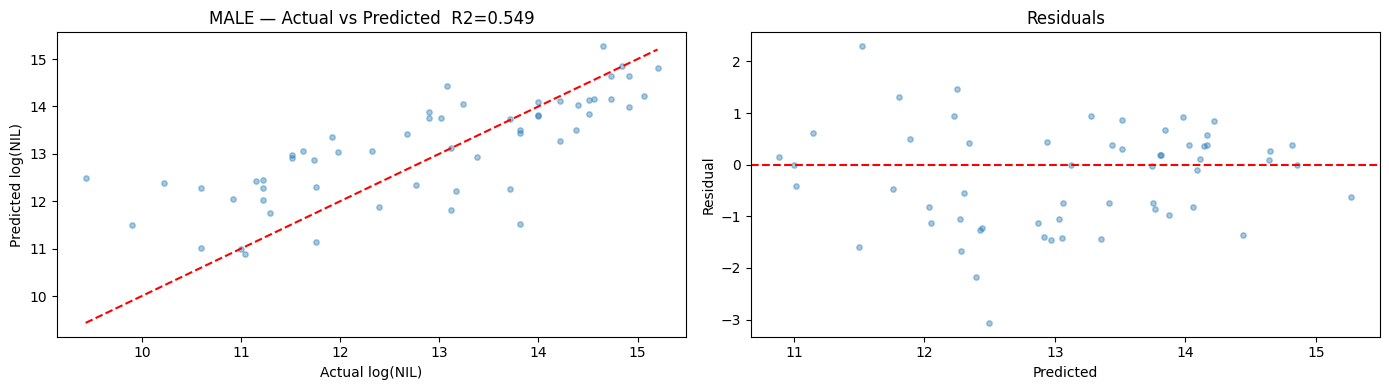

In [133]:
df_male = df_merged[df_merged['gender'] == 'MALE'].copy()
results_male = train_nil_model(df_male, 'MALE')


===== FEMALE =====
Records: 102
Value range: $2,000 - $750,000
Training rows after dropna: 102
Selected features: ['stlPg', 'rebPg', 'usagePct', 'astPg', 'ws', 'tsPct', 'fga3Pg', 'minsPg', 'fgaPg', 'blkPg', 'height', 'ptsScoredPg', 'conf_tier', 'isDraftProspect']
5-fold CV R2: 0.207 +/- 0.143
CV residual std (log scale): 1.182
Test R2  (log scale): 0.237
Test MAE (dollars):   $81,080
Median actual value:  $60,000
Tiers: Low < $41,650 | Mid < $120,000 | High >=


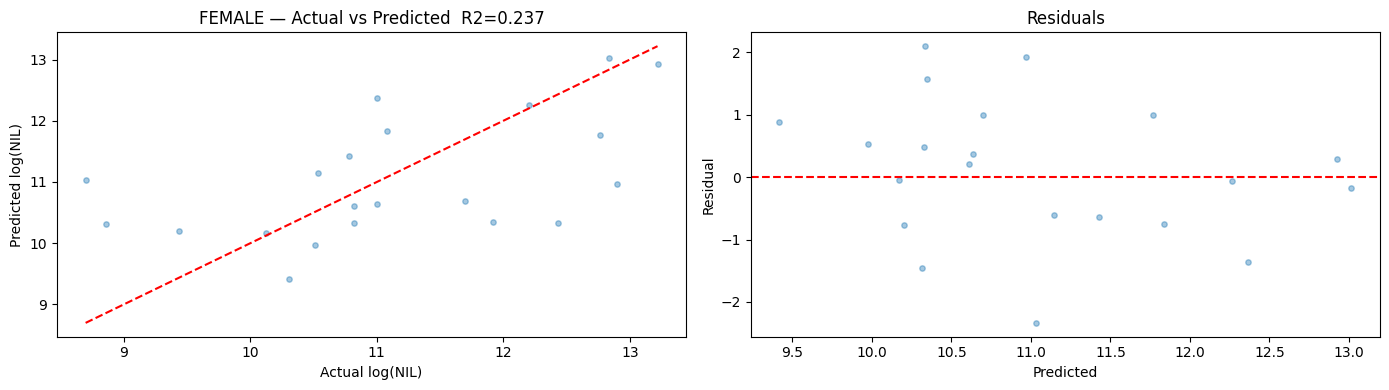

In [134]:
df_female = df_merged[df_merged['gender'] == 'FEMALE'].copy()
results_female = train_nil_model(df_female, 'FEMALE')

In [135]:
print('=== Men ===');
print(f'  Features: {results_male["features"]}')
print(f'  Tiers: Low < ${results_male["nil_low"]:,.0f}  |  High > ${results_male["nil_high"]:,.0f}')
print()
print('=== Women ===')
print(f'  Features: {results_female["features"]}')
print(f'  Tiers: Low < ${results_female["nil_low"]:,.0f}  |  High > ${results_female["nil_high"]:,.0f}')

=== Men ===
  Features: ['ws', 'astPg', 'rebPg', 'usagePct', 'fga3Pg', 'stlPg', 'ptsScoredPg', 'tsPct', 'fgaPg', 'minsPg', 'blkPg', 'height', 'conf_tier', 'isDraftProspect']
  Tiers: Low < $200,480  |  High > $1,000,000

=== Women ===
  Features: ['stlPg', 'rebPg', 'usagePct', 'astPg', 'ws', 'tsPct', 'fga3Pg', 'minsPg', 'fgaPg', 'blkPg', 'height', 'ptsScoredPg', 'conf_tier', 'isDraftProspect']
  Tiers: Low < $41,650  |  High > $120,000


In [141]:
def predict_players(result, comp_id, names):
    url = f'https://api.cbbanalytics.com/api/gs/player-agg-stats-public?competitionId={comp_id}&divisionId=1&scope=season'
    playerdf = pd.DataFrame(requests.get(url).json())

    top_confs = set(result['top_confs'])
    mid_confs = set(result['mid_confs'])
    playerdf['conf_tier'] = playerdf['conferenceId'].apply(
        lambda c: 3 if c in top_confs else (2 if c in mid_confs else 1)
    )

    test = playerdf[playerdf['fullName'].isin(names)]
    test_X = test[result['features']].apply(pd.to_numeric, errors='coerce').fillna(0)

    pred_log = result['model'].predict(test_X)
    half_std = result['resid_std'] * 0.25
    mid  = np.expm1(pred_log).round(0).astype(int)
    low  = np.expm1(pred_log - half_std).round(0).astype(int)
    high = np.expm1(pred_log + half_std).round(0).astype(int)

    for name, m, lo, hi in zip(test['fullName'].values, mid, low, high):
        tier = 'High Value' if m >= result['nil_high'] else ('Mid Value' if m >= result['nil_low'] else 'Low Value')
        print(f'  {name}: {tier}  ${lo:,} – ${hi:,}  (mid: ${m:,})')

In [148]:
print('Men (comp 41097):')
predict_players(results_male, 41097, ['Nick Dorn','Darius Adams','Money Williams', 'Flory Bidunga'])

# print('\nWomen (comp 41098):')
# predict_players(results_female, 41098, ['Azzi Fudd', 'Audi Crooks','Addi Mack','Nunu Agara'])

Men (comp 41097):
  Money Williams: High Value  $1,557,763 – $2,584,414  (mid: $2,006,466)
  Flory Bidunga: High Value  $1,457,057 – $2,417,338  (mid: $1,876,752)
  Nick Dorn: Low Value  $147,156 – $244,140  (mid: $189,543)
  Darius Adams: Mid Value  $389,245 – $645,780  (mid: $501,365)


In [149]:
import joblib
import json

In [150]:
for gender, result in [('male', results_male), ('female', results_female)]:
    pkl_path  = f'nil_regressor_{gender}.pkl'
    meta_path = f'nil_meta_{gender}.json'

    joblib.dump(result['model'], pkl_path)

    meta = {
        'features':           result['features'],
        'nil_low_threshold':  result['nil_low'],
        'nil_high_threshold': result['nil_high'],
        'conf_tier_top':      result['top_confs'],
        'conf_tier_mid':      result['mid_confs'],
        'resid_std':          result['resid_std'],
    }
    with open(meta_path, 'w') as f:
        json.dump(meta, f, indent=2)

    print(f'Exported: {pkl_path}, {meta_path}')
    print(f'  Features: {result["features"]}')
    print(f'  Resid std: {result["resid_std"]:.3f}')

Exported: nil_regressor_male.pkl, nil_meta_male.json
  Features: ['ws', 'astPg', 'rebPg', 'usagePct', 'fga3Pg', 'stlPg', 'ptsScoredPg', 'tsPct', 'fgaPg', 'minsPg', 'blkPg', 'height', 'conf_tier', 'isDraftProspect']
  Resid std: 1.012
Exported: nil_regressor_female.pkl, nil_meta_female.json
  Features: ['stlPg', 'rebPg', 'usagePct', 'astPg', 'ws', 'tsPct', 'fga3Pg', 'minsPg', 'fgaPg', 'blkPg', 'height', 'ptsScoredPg', 'conf_tier', 'isDraftProspect']
  Resid std: 1.182
